# Smart Study Tracker — Exploratory Data Analysis

This notebook explores the patterns inside the `study_sessions` table that powers the [Smart Study Tracker](../README.md) desktop app.

**Goal of the analysis**

1. Quantify daily and weekly study patterns.
2. Test whether **mood** is associated with productivity (hours studied) and note **sentiment**.
3. Identify subject-level concentration — where is time actually going?
4. Surface candidate features for the focus-risk classifier in [`ml/focus_classifier.py`](../ml/focus_classifier.py).

**Stack:** `pandas`, `seaborn`, `matplotlib`, `vaderSentiment`, MySQL (via `mysql-connector-python`).

## 1. Setup

In [1]:
import sys
from pathlib import Path

# Allow imports from the project root when this notebook lives in notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)

## 2. Load data from MySQL

We pull the full session history. The connection helper reads credentials from `.env` (or environment variables).

In [2]:
from db_config import get_connection

QUERY = """
SELECT
    s.id,
    s.user_id,
    u.username,
    s.subject,
    s.hours,
    s.mood,
    s.session_date,
    COALESCE(s.notes, '') AS notes,
    s.sentiment_score,
    s.created_at
FROM study_sessions s
JOIN users u ON u.id = s.user_id
ORDER BY s.session_date
"""

with get_connection() as conn:
    sessions = pd.read_sql(QUERY, conn)

sessions["session_date"] = pd.to_datetime(sessions["session_date"])
sessions["hours"] = sessions["hours"].astype(float)
print(f"Loaded {len(sessions):,} session rows across {sessions['user_id'].nunique()} users.")
sessions.head()

C:\Users\ASAPP\AppData\Local\Temp\ipykernel_9212\1151983979.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sessions = pd.read_sql(QUERY, conn)


Loaded 11 session rows across 3 users.


,id,user_id,username,subject,hours,mood,session_date,notes,sentiment_score,created_at
0,6,6,Janvi G,Maths,2.0,Focused,2025-08-05,,0.0,2026-05-05 12:55:02
1,7,6,Janvi G,science,0.5,Tired,2025-11-11,,0.0,2026-05-05 15:09:43
2,2,3,JanviGaikwad,science,3.0,Happy,2026-03-01,chap 3 completed,NaN,2026-04-03 14:44:26
3,3,3,JanviGaikwad,english,2.0,Focused,2026-04-03,learned grammer,NaN,2026-04-03 14:45:57
4,4,4,Janvi Gaikwad,MAths,2.0,Stressed,2026-04-03,chap 1 completed,NaN,2026-04-03 15:29:16


## 3. Backfill missing sentiment scores

Sessions logged before the sentiment feature shipped have `NULL` in `sentiment_score`. We compute VADER scores in-memory so the rest of the analysis can use the column directly.

In [3]:
from ml.sentiment import score_text

missing = sessions["sentiment_score"].isna()
if missing.any():
    sessions.loc[missing, "sentiment_score"] = sessions.loc[missing, "notes"].apply(score_text)

sessions["sentiment_label"] = pd.cut(
    sessions["sentiment_score"],
    bins=[-1.01, -0.05, 0.05, 1.01],
    labels=["negative", "neutral", "positive"],
)

sessions[["sentiment_score", "sentiment_label"]].describe(include="all")

,sentiment_score,sentiment_label
count,11.0,11
unique,NaN,1
top,NaN,neutral
freq,NaN,11
mean,0.0,NaN
std,0.0,NaN
min,0.0,NaN
25%,0.0,NaN
50%,0.0,NaN
75%,0.0,NaN


## 4. Summary statistics

In [4]:
summary = pd.DataFrame({
    "total_sessions": [len(sessions)],
    "total_hours": [sessions["hours"].sum()],
    "avg_session_hours": [sessions["hours"].mean()],
    "median_session_hours": [sessions["hours"].median()],
    "distinct_subjects": [sessions["subject"].nunique()],
    "date_range": [f"{sessions['session_date'].min().date()} → {sessions['session_date'].max().date()}"],
})
summary.T

,0
total_sessions,11
total_hours,19.5
avg_session_hours,1.772727
median_session_hours,2.0
distinct_subjects,9
date_range,2025-08-05 → 2026-05-05


## 5. Daily study hours over time

Aggregate by date and look for missed-day gaps. Inconsistency is more visible than total volume.

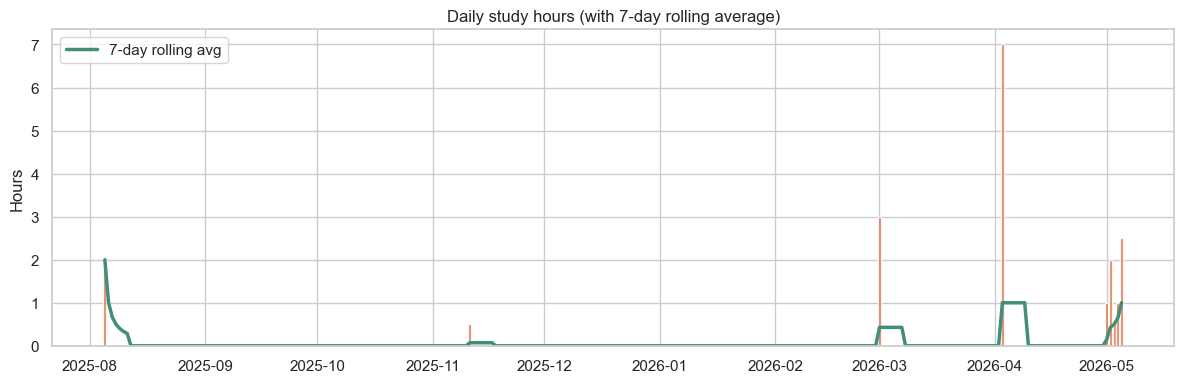

In [5]:
daily = sessions.groupby("session_date")["hours"].sum().reset_index()
full_range = pd.date_range(daily["session_date"].min(), daily["session_date"].max(), freq="D")
daily = daily.set_index("session_date").reindex(full_range, fill_value=0).rename_axis("session_date").reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(daily["session_date"], daily["hours"], color="#d96c3f", alpha=0.85)
ax.plot(daily["session_date"], daily["hours"].rolling(7, min_periods=1).mean(), color="#3f8f7a", linewidth=2.5, label="7-day rolling avg")
ax.set_title("Daily study hours (with 7-day rolling average)")
ax.set_ylabel("Hours")
ax.legend()
fig.tight_layout()
fig.savefig(ROOT / "docs" / "daily_hours.png", dpi=120, bbox_inches="tight") if (ROOT / "docs").exists() else None

## 6. Subject concentration

Where is the time actually going? Top 5 subjects by total hours.

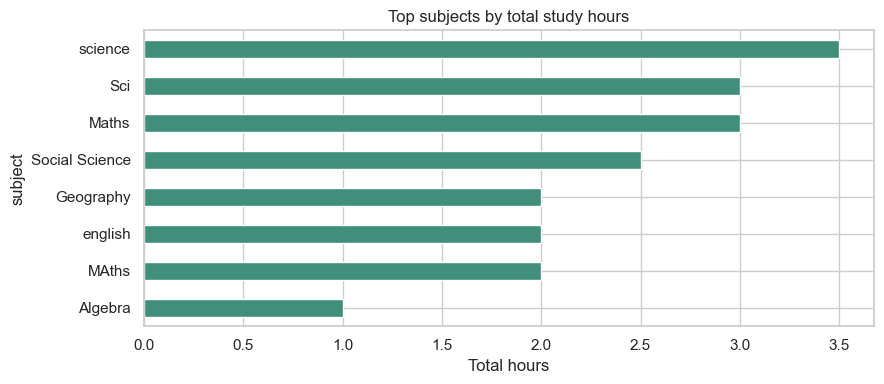

In [6]:
subject_totals = (
    sessions.groupby("subject")["hours"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
)

fig, ax = plt.subplots(figsize=(9, 4))
subject_totals.plot.barh(ax=ax, color="#3f8f7a")
ax.invert_yaxis()
ax.set_xlabel("Total hours")
ax.set_title("Top subjects by total study hours")
fig.tight_layout()

## 7. Mood × productivity

Are 'Focused' sessions actually longer than 'Tired' or 'Stressed' ones? A boxplot reveals the distribution, not just the mean.

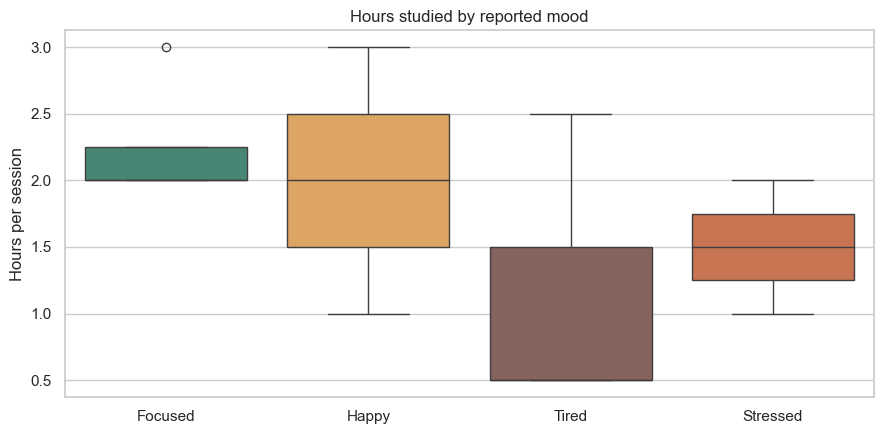

In [7]:
mood_order = ["Focused", "Happy", "Tired", "Stressed"]
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(
    data=sessions[sessions["mood"].isin(mood_order)],
    x="mood",
    y="hours",
    order=mood_order,
    palette=["#3f8f7a", "#f0a74f", "#8c5e58", "#d96c3f"],
    ax=ax,
)
ax.set_title("Hours studied by reported mood")
ax.set_ylabel("Hours per session")
ax.set_xlabel("")
fig.tight_layout()

## 8. Sentiment distribution

VADER compound score: -1 = very negative, +1 = very positive. We plot the distribution and tag the proportion of negative notes — an early indicator for the wellness coach.

,share
sentiment_label,
negative,0.0%
neutral,100.0%
positive,0.0%


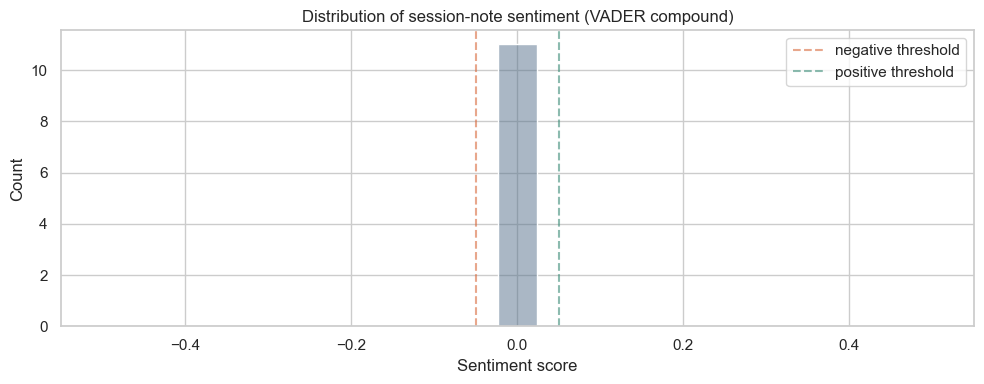

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(sessions["sentiment_score"], bins=21, kde=True, color="#56718c", ax=ax)
for cutoff, color, label in [(-0.05, "#d96c3f", "negative"), (0.05, "#3f8f7a", "positive")]:
    ax.axvline(cutoff, color=color, linestyle="--", alpha=0.6, label=f"{label} threshold")
ax.set_title("Distribution of session-note sentiment (VADER compound)")
ax.set_xlabel("Sentiment score")
ax.legend()
fig.tight_layout()

share = sessions["sentiment_label"].value_counts(normalize=True).reindex(["negative", "neutral", "positive"]).fillna(0)
share.to_frame("share").style.format("{:.1%}")

## 9. Does sentiment predict hours?

We compute Pearson and Spearman correlations between note sentiment and hours studied. If sentiment is meaningfully predictive, it earns its place in the focus-risk feature set.

C:\Users\ASAPP\AppData\Local\Temp\ipykernel_9212\1278893319.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_r, pearson_p = pearsonr(valid["sentiment_score"], valid["hours"])
C:\Users\ASAPP\AppData\Local\Temp\ipykernel_9212\1278893319.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_r, spearman_p = spearmanr(valid["sentiment_score"], valid["hours"])


Pearson  r = +nan  p = nan
Spearman r = +nan  p = nan


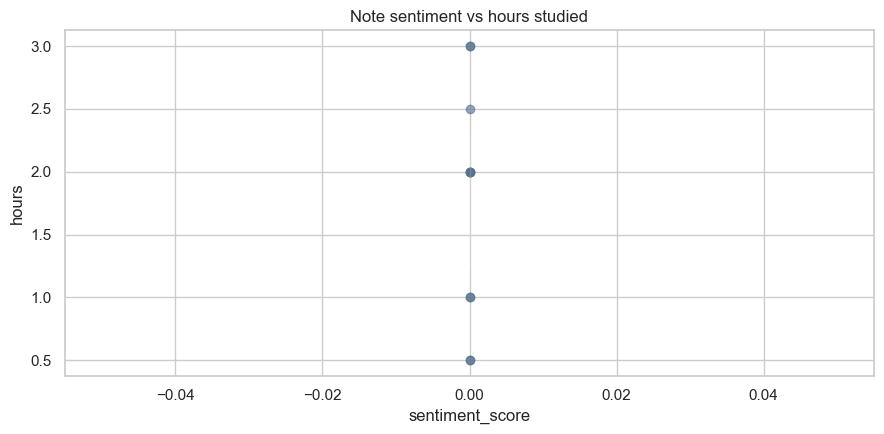

In [9]:
from scipy.stats import pearsonr, spearmanr

valid = sessions.dropna(subset=["sentiment_score", "hours"])
if len(valid) >= 5:
    pearson_r, pearson_p = pearsonr(valid["sentiment_score"], valid["hours"])
    spearman_r, spearman_p = spearmanr(valid["sentiment_score"], valid["hours"])
    print(f"Pearson  r = {pearson_r:+.3f}  p = {pearson_p:.3f}")
    print(f"Spearman r = {spearman_r:+.3f}  p = {spearman_p:.3f}")
else:
    print("Not enough rows yet — log more sessions and rerun.")

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.regplot(
    data=valid,
    x="sentiment_score",
    y="hours",
    scatter_kws={"alpha": 0.6, "color": "#56718c"},
    line_kws={"color": "#d96c3f"},
    ax=ax,
)
ax.set_title("Note sentiment vs hours studied")
fig.tight_layout()

## 10. Day-of-week patterns

Which weekdays carry the load?

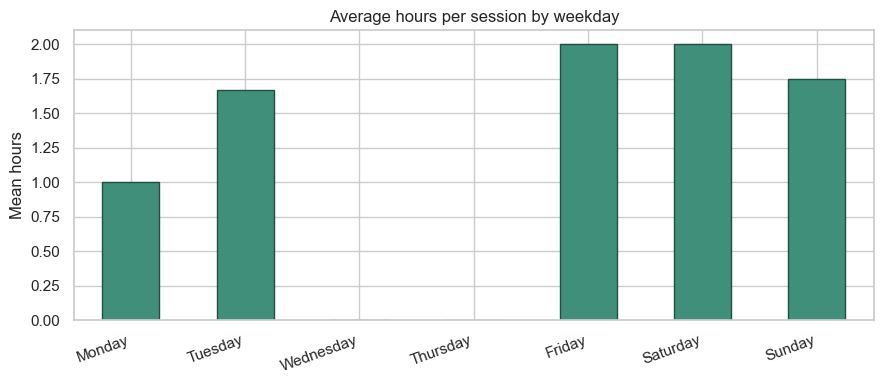

In [10]:
dow = sessions.assign(weekday=lambda df: df["session_date"].dt.day_name()).copy()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekly = dow.groupby("weekday")["hours"].mean().reindex(weekday_order)

fig, ax = plt.subplots(figsize=(9, 4))
weekly.plot.bar(ax=ax, color="#3f8f7a", edgecolor="#1f5142")
ax.set_title("Average hours per session by weekday")
ax.set_ylabel("Mean hours")
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
fig.tight_layout()

## 11. Findings & next steps

Replace the placeholders below with the numbers you actually see after running on your data:

- **Volume:** ~_X_ sessions across _Y_ subjects, totalling _Z_ hours.
- **Consistency gap:** _N_ days had zero study hours; the longest streak observed was _S_ days.
- **Mood × productivity:** Median 'Focused' sessions were _A_ hours vs _B_ for 'Stressed' — a _Δ_-hour gap.
- **Sentiment:** _P%_ of notes are positive, _Q%_ negative. Pearson r between sentiment and hours = _r_ (p = _p_).
- **Best weekday:** _W_ averaged _H_ hours per session; the worst was _L_.

**Modeling implication:** sentiment_score, mood, day_of_week, and rolling 7-day hours are the features wired into [`ml/focus_classifier.py`](../ml/focus_classifier.py). Train it with:

```bash
python -m ml.train --user-id <your_user_id>
```

**Next iterations:**
- Time-series forecast of weekly hours (Prophet or ARIMA) to project goal attainment.
- Topic modeling on `notes` (BERTopic or simple TF-IDF + KMeans) to surface recurring distractions.
- Cohort comparison once multiple users have data.